In [1]:
!pip install faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

fake = Faker()

num_rows = 2000
start_date = datetime(2023, 1, 1)

# Initialize lists
dates = []
day_number = []
active_users = []
avg_data_per_user = []
peak_hour_traffic = []
video_streaming = []
voice_calls = []
iot_devices = []
network_load = []
packet_loss = []
latency_ms = []

for i in range(num_rows):
    current_date = start_date + timedelta(days=i)

    day_number.append(i)

    active_users_val = random.randint(800, 2000)
    avg_data_val = round(random.uniform(0.5, 5.0), 2)
    peak_traffic_val = round(avg_data_val * active_users_val * random.uniform(0.8, 1.2), 2)
    video_val = round(peak_traffic_val * random.uniform(0.4, 0.7), 2)
    voice_val = round(random.uniform(50, 200), 2)
    iot_val = random.randint(50, 500)
    network_load_val = round(random.uniform(30, 95), 2)
    packet_loss_val = round(random.uniform(0, 5), 2)
    latency_val = round(random.uniform(10, 100), 2)

    # Append values
    dates.append(current_date.strftime("%Y-%m-%d"))
    active_users.append(active_users_val)
    avg_data_per_user.append(avg_data_val)
    peak_hour_traffic.append(peak_traffic_val)
    video_streaming.append(video_val)
    voice_calls.append(voice_val)
    iot_devices.append(iot_val)
    network_load.append(network_load_val)
    packet_loss.append(packet_loss_val)
    latency_ms.append(latency_val)

# Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "day_number": day_number,
    "active_users": active_users,
    "avg_data_per_user": avg_data_per_user,
    "peak_hour_traffic": peak_hour_traffic,
    "video_streaming": video_streaming,
    "voice_calls": voice_calls,
    "iot_devices": iot_devices,
    "network_load": network_load,
    "packet_loss": packet_loss,
    "latency_ms": latency_ms
})

df.head()


,date,day_number,active_users,avg_data_per_user,peak_hour_traffic,video_streaming,voice_calls,iot_devices,network_load,packet_loss,latency_ms
0,2023-01-01,0,1036,2.35,2095.28,1307.15,157.62,466,93.39,2.42,40.51
1,2023-01-02,1,1839,2.71,4518.61,2222.90,55.92,473,90.09,2.29,26.90
2,2023-01-03,2,1831,1.23,2062.97,859.96,151.39,341,55.89,2.84,24.55
3,2023-01-04,3,1482,4.45,6650.66,2737.24,141.49,246,34.21,0.61,25.47
4,2023-01-05,4,1664,4.72,7960.68,3232.08,143.16,343,30.65,3.78,57.31


In [3]:
X = df[['day_number']]
y = df['peak_hour_traffic']


In [4]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [6]:
y_pred = model.predict(X_test)

# Show first 10 comparisons
comparison = pd.DataFrame({
    "Day": X_test['day_number'],
    "Actual Traffic": y_test.values,
    "Predicted Traffic": y_pred.round(2)
})
comparison.head(10)


,Day,Actual Traffic,Predicted Traffic
1600,1600,2031.52,3723.89
1601,1601,1936.08,3723.71
1602,1602,608.74,3723.52
1603,1603,1658.33,3723.33
1604,1604,1508.04,3723.14
1605,1605,7451.06,3722.95
1606,1606,1472.44,3722.76
1607,1607,6061.65,3722.57
1608,1608,1790.84,3722.38
1609,1609,4040.39,3722.19


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))


Mean Absolute Error (MAE): 1830.66
Mean Squared Error (MSE): 4992536.57


In [15]:
import numpy as np
import pandas as pd

n_days = int(input("Enter number of future days to predict: "))

future_days = [[i] for i in range(df['day_number'].max() + 1, df['day_number'].max() + 1 + n_days)]
future_pred = model.predict(future_days)

# Convert 'date' column to datetime objects before performing operations
df['date'] = pd.to_datetime(df['date'])
future_dates = pd.date_range(df['date'].max() + pd.Timedelta(days=1), periods=n_days)

future_df = pd.DataFrame({
    "Date": future_dates.strftime("%Y-%m-%d"),
    "Predicted Traffic (GB)": future_pred.round(2)
})

future_df

Enter number of future days to predict: 300


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Predicted Traffic (GB)
0,2028-06-23,3648.04
1,2028-06-24,3647.85
2,2028-06-25,3647.66
3,2028-06-26,3647.47
4,2028-06-27,3647.28
...,...,...
295,2029-04-14,3592.09
296,2029-04-15,3591.90
297,2029-04-16,3591.71
298,2029-04-17,3591.53


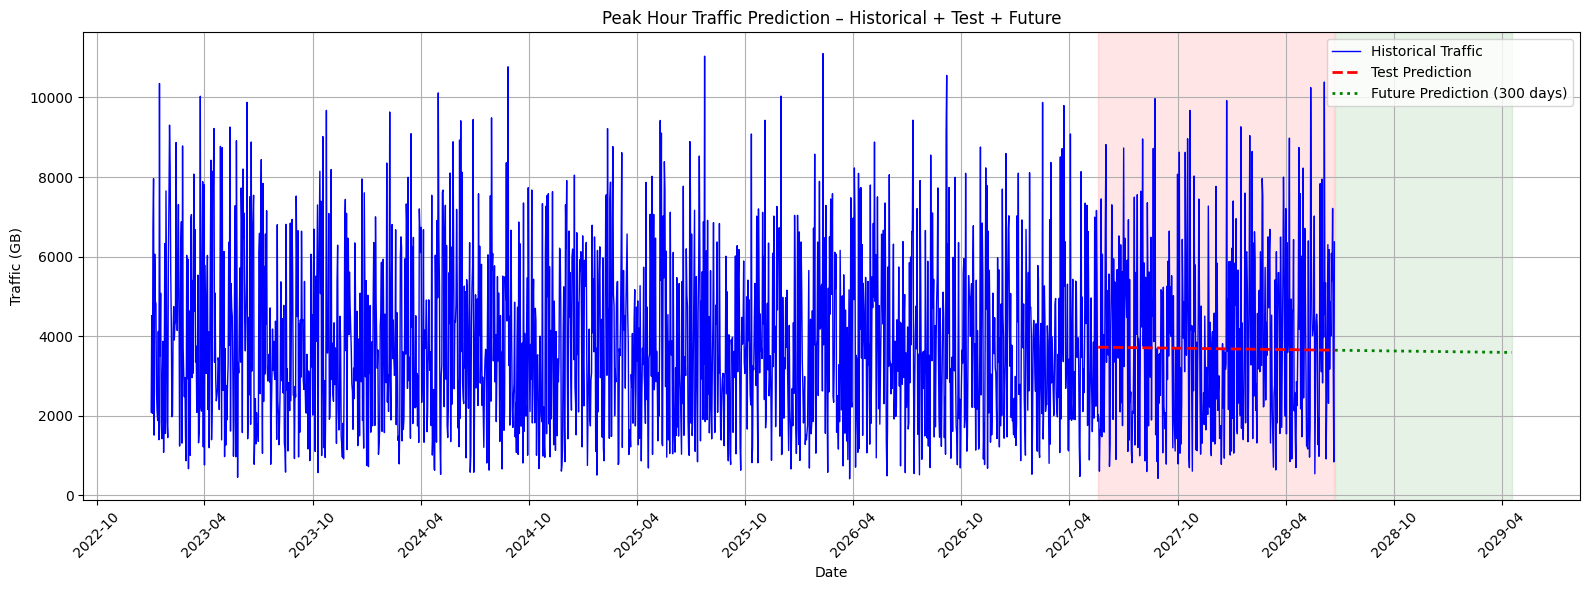

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(16,6))

# Historical traffic
plt.plot(df['date'], df['peak_hour_traffic'], label='Historical Traffic', color='blue', linewidth=1)

# Test prediction
plt.plot(X_test['day_number'].map(lambda x: df['date'].iloc[x]), y_pred,
         label='Test Prediction', color='red', linestyle='--', linewidth=2)

# Future prediction
plt.plot(future_dates, future_pred, label=f'Future Prediction ({n_days} days)', color='green', linestyle=':', linewidth=2)

# Highlight test & future periods
plt.axvspan(df['date'].iloc[X_test.index[0]], df['date'].iloc[X_test.index[-1]], color='red', alpha=0.1)
plt.axvspan(future_dates[0], future_dates[-1], color='green', alpha=0.1)

# Axis labels and formatting
plt.xlabel('Date')
plt.ylabel('Traffic (GB)')
plt.title('Peak Hour Traffic Prediction – Historical + Test + Future')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
df.to_csv("synthetic_telecom_2000.csv", index=False)
future_df.to_csv("future_peak_hour_traffic.csv", index=False)
